Question 6: Write a Python program to generate a binomial distribution with n=10 and
p=0.5, then plot its histogram.

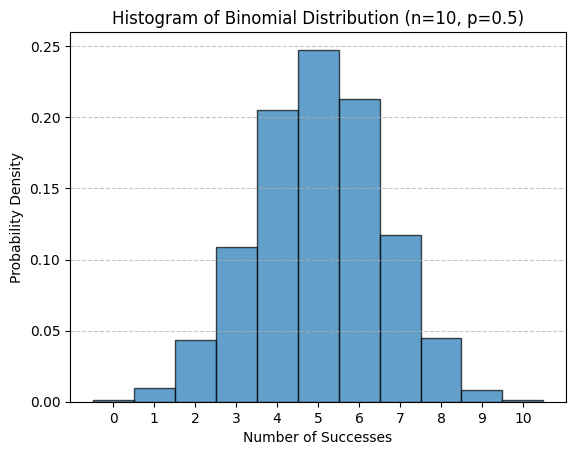

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters for the binomial distribution
n = 10  # Number of trials
p = 0.5 # Probability of success

# Generate random samples from a binomial distribution
# We generate a large number of samples (e.g., 10000) to get a good representation of the distribution
num_samples = 10000
binomial_samples = np.random.binomial(n, p, num_samples)

# Plot the histogram of the generated samples
plt.hist(binomial_samples, bins=np.arange(n + 2) - 0.5, density=True, edgecolor='black', alpha=0.7)

# Add title and labels
plt.title(f'Histogram of Binomial Distribution (n={n}, p={p})')
plt.xlabel('Number of Successes')
plt.ylabel('Probability Density')
plt.xticks(range(n + 1)) # Ensure x-axis ticks are at integer values representing number of successes
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()

Question 7: Implement hypothesis testing using Z-statistics for a sample dataset in
Python. Show the Python code and interpret the results.
sample_data = [49.1, 50.2, 51.0, 48.7, 50.5, 49.8, 50.3, 50.7, 50.2, 49.6,
                        50.1, 49.9, 50.8, 50.4, 48.9, 50.6, 50.0, 49.7, 50.2, 49.5, 50.1, 50.3, 50.4, 50.5, 50.0, 50.7, 49.3, 49.8, 50.2, 50.9, 50.3, 50.4, 50.0, 49.7, 50.5, 49.9] .
ANS = For a Z-test to be appropriate, the following assumptions are typically made:     
* Normality: The sample data is drawn from a normally distributed population, or the sample size is sufficiently large (n > 30) for the Central Limit Theorem to apply.
* Known Population Standard Deviation: The population standard deviation (\(\sigma \)) is known. If it's unknown, a t-test is generally more appropriate. In this example, we will assume a hypothetical population standard deviation for demonstration purposes.
* Independence: The observations in the sample are independent.

In [8]:
import numpy as np
import scipy.stats as stats

# Sample data
sample_data = [49.1, 50.2, 51.0, 48.7, 50.5, 49.8, 50.3, 50.7, 50.2, 49.6,
                        50.1, 49.9, 50.8, 50.4, 48.9, 50.6, 50.0, 49.7, 50.2, 49.5,
                        50.1, 50.3, 50.4, 50.5, 50.0, 50.7, 49.3, 49.8, 50.2, 50.9,
                        50.3, 50.4, 50.0, 49.7, 50.5, 49.9]

# Hypothesized population mean (null hypothesis)
hypothesized_mean = 50

# Population standard deviation (assumed for Z-test - this is crucial for a Z-test)
population_std_dev = 1.0

# Calculate sample statistics
sample_mean = np.mean(sample_data)
sample_size = len(sample_data)

# Calculate the Z-statistic manually
# Z = (sample_mean - hypothesized_mean) / (population_std_dev / sqrt(sample_size))
standard_error_mean = population_std_dev / np.sqrt(sample_size)
z_statistic = (sample_mean - hypothesized_mean) / standard_error_mean

# Calculate the two-tailed p-value
# For a two-tailed test, p-value = 2 * P(Z > |z_statistic|)
p_value = 2 * stats.norm.sf(abs(z_statistic))

# Significance level
alpha = 0.05

print(f"Sample Mean: {sample_mean:.4f}")
print(f"Z-Statistic: {z_statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

# Interpret the results
if p_value < alpha:
    print(f"Reject the null hypothesis (H0) at alpha = {alpha}.")
    print(f"Conclusion: The sample mean is significantly different from the hypothesized population mean of {hypothesized_mean}.")
else:
    print(f"Fail to reject the null hypothesis (H0) at alpha = {alpha}.")
    print(f"Conclusion: There is no statistically significant evidence to suggest the sample mean is different from the hypothesized population mean of {hypothesized_mean}.")

Sample Mean: 50.0889
Z-Statistic: 0.5333
P-Value: 0.5938
Fail to reject the null hypothesis (H0) at alpha = 0.05.
Conclusion: There is no statistically significant evidence to suggest the sample mean is different from the hypothesized population mean of 50.


Question 8: Write a Python script to simulate data from a normal distribution and
calculate the 95% confidence interval for its mean. Plot the data using Matplotlib.

ANS = To solve this, you can use Python with the numpy, scipy.stats, and matplotlib.pyplot libraries. The script will simulate the data, calculate the confidence interval using the t-distribution (which is appropriate for sample data with unknown population standard deviation), and then plot the results.


Sample Mean: 49.85
Sample Standard Deviation: 10.29
95% Confidence Interval for the Mean: (49.21, 50.49)


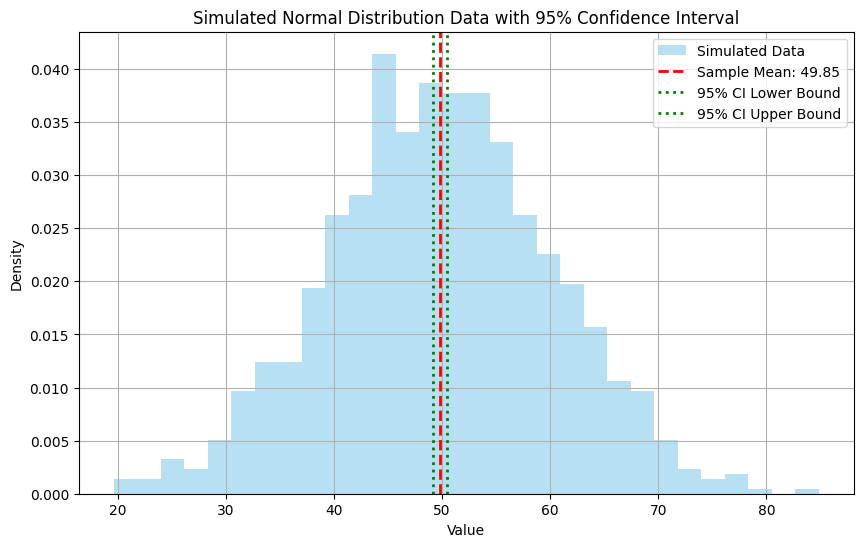

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 1. Simulate data from a normal distribution
mean_true = 50
std_dev_true = 10
sample_size = 1000
data = np.random.normal(loc=mean_true, scale=std_dev_true, size=sample_size)

# 2. Calculate the 95% confidence interval for the mean
sample_mean = np.mean(data)
sample_std = np.std(data, ddof=1)  # Use ddof=1 for sample standard deviation
standard_error = sample_std / np.sqrt(sample_size)

# For a 95% confidence interval, the critical t-value (or z-value for large samples)
# can be found using the percent point function (ppf) of the t-distribution.
# Degrees of freedom (df) = sample_size - 1
confidence_level = 0.95
alpha = 1 - confidence_level
t_critical = stats.t.ppf(1 - alpha / 2, df=sample_size - 1)

margin_of_error = t_critical * standard_error
confidence_interval_lower = sample_mean - margin_of_error
confidence_interval_upper = sample_mean + margin_of_error

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")
print(f"95% Confidence Interval for the Mean: ({confidence_interval_lower:.2f}, {confidence_interval_upper:.2f})")

# 3. Plot the data and confidence interval
plt.figure(figsize=(10, 6))
plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', label='Simulated Data')
plt.axvline(sample_mean, color='red', linestyle='dashed', linewidth=2, label=f'Sample Mean: {sample_mean:.2f}')
plt.axvline(confidence_interval_lower, color='green', linestyle='dotted', linewidth=2, label='95% CI Lower Bound')
plt.axvline(confidence_interval_upper, color='green', linestyle='dotted', linewidth=2, label='95% CI Upper Bound')

plt.title('Simulated Normal Distribution Data with 95% Confidence Interval')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

**Explanation:**
* Data Simulation: np.random.normal() is used to generate a sample of 100 data points from a normal distribution with a specified mean (50) and standard deviation (10).
* Confidence Interval Calculation:
- The sample mean and standard error of the mean (st.sem) are calculated.
- The scipy.stats.t.interval() function is a convenient way to compute the confidence interval using the t-distribution, which is standard practice when the true population standard deviation is unknown and estimated from the sample.
* Plotting: matplotlib.pyplot is used to create a histogram of the data. Vertical lines (axvline) indicate the sample mean and the upper and lower bounds of the 95% confidence interval. This visualization helps show where the mean falls and the range of the confidence interval relative to the data.

Question 9: Write a Python function to calculate the Z-scores from a dataset and
visualize the standardized data using a histogram. Explain what the Z-scores represent
in terms of standard deviations from the mean.

ANS = **Explanation of Z-scores:**
    A Z-score (also known as a standard score) represents the number of standard deviations a particular data point is away from the mean of the dataset.
* Z-score of 0: Indicates the data point is exactly at the mean.
* Positive Z-score: Indicates the data point is above the mean. For example, a Z-score of +1 means the data point is one standard deviation above the mean. A Z-score of +2 means it's two standard deviations above the mean, and so on.
* Negative Z-score: Indicates the data point is below the mean. For instance, a Z-score of -1 means the data point is one standard deviation below the mean. A Z-score of -2 means it's two standard deviations below the mean.
  "Z-scores are a crucial tool in statistics for standardizing data, allowing for comparisons between data points from different distributions and for identifying outliers"

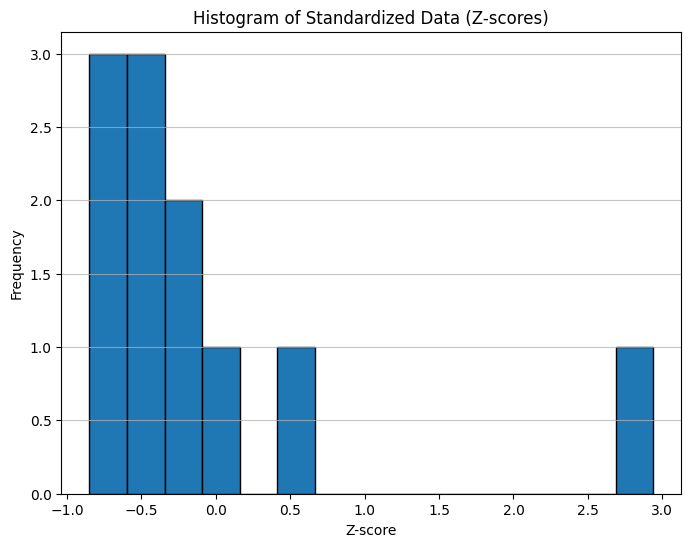

Calculated Z-scores: [-0.84928533 -0.34430486 -0.34430486 -0.09181463 -0.34430486 -0.59679509
  0.1606756  -0.09181463  0.41316583 -0.84928533  2.93806815]


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_z_scores(data):
    """
    Calculates Z-scores for a dataset and visualizes the standardized data
    using a histogram.

    Args:
        data (list or np.array): The input dataset.

    Returns:
        np.array: An array of calculated Z-scores.
    """
    data = np.array(data) # Ensure data is a NumPy array
    mean = np.mean(data)
    std_dev = np.std(data)

    if std_dev == 0:
        print("Standard deviation is zero. Z-scores cannot be calculated.")
        return np.zeros_like(data)

    z_scores = (data - mean) / std_dev

    plt.figure(figsize=(8, 6))
    plt.hist(z_scores, bins=15, edgecolor='black')
    plt.title('Histogram of Standardized Data (Z-scores)')
    plt.xlabel('Z-score')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    return z_scores

# Example usage:
dataset = [10, 12, 12, 13, 12, 11, 14, 13, 15, 10, 25]
calculated_z_scores = analyze_z_scores(dataset)
print("Calculated Z-scores:", calculated_z_scores)